In [1]:
# Male × Minimal Data Analysis
# Goal: Find patterns and intelligently reduce excess data
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the exported data
df = pd.read_csv('maleXminimal.csv')

print(f"✅ Loaded {len(df)} rows × {len(df.columns)} columns")
print(f"\nFirst 5 rows:")
df.head()

✅ Loaded 139 rows × 16 columns

First 5 rows:


,Age,Gender,Little interest or pleasure in doing things,"Feeling down, depressed, or hopeless","Trouble falling or staying asleep, or sleeping too much",Feeling tired or having little energy,Poor appetite or overeating,Feeling bad about yourself—or that you are a failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual,Thoughts that you would be better off dead or of hurting yourself in some way,PHQ_Total,PHQ_Severity,Sleep Quality,Study Pressure,Financial Pressure
0,22,Male,More than half the days,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,More than half the days,Not at all,4,Minimal,Good,Good,Average
1,24,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,More than half the days,Not at all,2,Minimal,Good,Average,Good
2,19,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,0,Minimal,Good,Good,Good
3,19,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Several days,Not at all,Not at all,1,Minimal,Bad,Good,Bad
4,25,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Several days,1,Minimal,Good,Good,Good


📊 PATTERN ANALYSIS:
Total rows: 139
Unique patterns: 132
Redundant rows: 7 (5.0%)

🔁 MOST REPEATED PATTERNS (count ≥ 2):
Number of repeated patterns: 5
Total rows in repeated patterns: 12


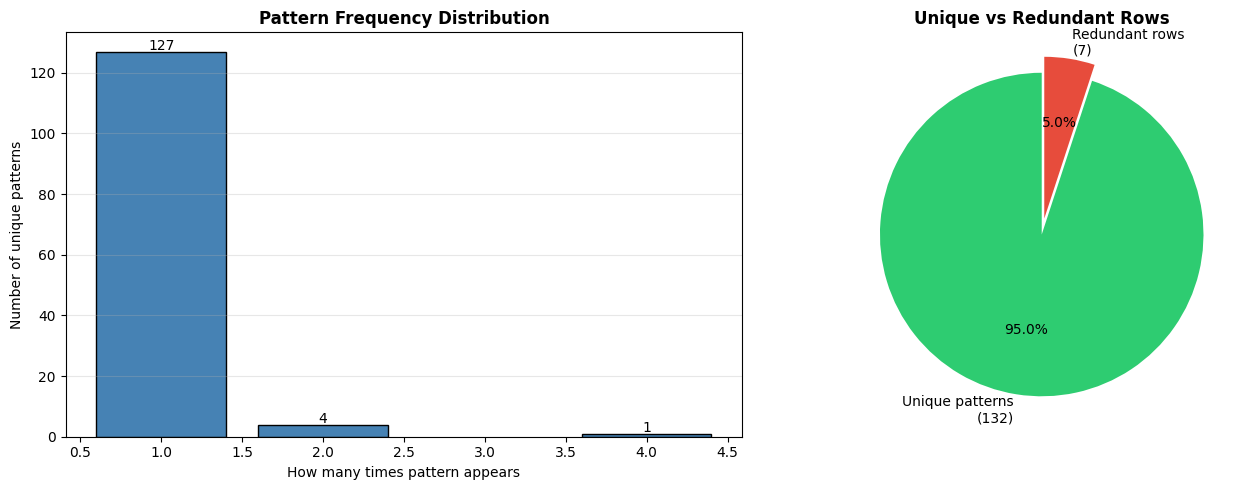


📋 TOP 10 MOST COMMON PATTERNS:
   Gender Little interest or pleasure in doing things    Feeling down, depressed, or hopeless     Trouble falling or staying asleep, or sleeping too much     Feeling tired or having little energy     Poor appetite or overeating   Feeling bad about yourself—or that you are a failure or have let yourself or your family down   Trouble concentrating on things, such as reading the newspaper or watching television   Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual   Thoughts that you would be better off dead or of hurting yourself in some way    PHQ_Total PHQ_Severity Sleep Quality Study Pressure Financial Pressure  count
32   Male                                   Not at all                               Not at all                                                  Not at all                                Not at all                      Not at 

In [2]:
# STEP 2: Find Similar/Duplicate Patterns
# ========================================

# Define columns to compare (exclude Age as it varies naturally)
pattern_cols = [col for col in df.columns if col != 'Age']

# Group by all pattern columns to find duplicates
pattern_groups = df.groupby(pattern_cols).size().reset_index(name='count')
pattern_groups = pattern_groups.sort_values('count', ascending=False)

print("📊 PATTERN ANALYSIS:")
print("=" * 60)
print(f"Total rows: {len(df)}")
print(f"Unique patterns: {len(pattern_groups)}")
print(f"Redundant rows: {len(df) - len(pattern_groups)} ({(len(df) - len(pattern_groups))/len(df)*100:.1f}%)")

# Show most common patterns
print("\n🔁 MOST REPEATED PATTERNS (count ≥ 2):")
repeated = pattern_groups[pattern_groups['count'] >= 2]
print(f"Number of repeated patterns: {len(repeated)}")
print(f"Total rows in repeated patterns: {repeated['count'].sum()}")

# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of pattern frequencies
ax1 = axes[0]
freq_counts = pattern_groups['count'].value_counts().sort_index()
ax1.bar(freq_counts.index, freq_counts.values, color='steelblue', edgecolor='black')
ax1.set_title('Pattern Frequency Distribution', fontweight='bold')
ax1.set_xlabel('How many times pattern appears')
ax1.set_ylabel('Number of unique patterns')
ax1.grid(True, alpha=0.3, axis='y')

# Add labels
for i, (x, y) in enumerate(zip(freq_counts.index, freq_counts.values)):
    ax1.text(x, y + 0.5, str(y), ha='center', fontsize=10)

# 2. Pie chart: Unique vs Redundant
ax2 = axes[1]
unique_count = len(pattern_groups)
redundant_count = len(df) - unique_count
ax2.pie([unique_count, redundant_count], 
        labels=[f'Unique patterns\n({unique_count})', f'Redundant rows\n({redundant_count})'],
        colors=['#2ecc71', '#e74c3c'], 
        autopct='%1.1f%%', 
        startangle=90,
        explode=[0, 0.1])
ax2.set_title('Unique vs Redundant Rows', fontweight='bold')

plt.tight_layout()
plt.show()

# Display top 10 most common patterns
print("\n📋 TOP 10 MOST COMMON PATTERNS:")
print(repeated.head(10).to_string())

BEFORE: 139 rows
AFTER:  132 rows
REMOVED: 7 redundant rows (5.0%)


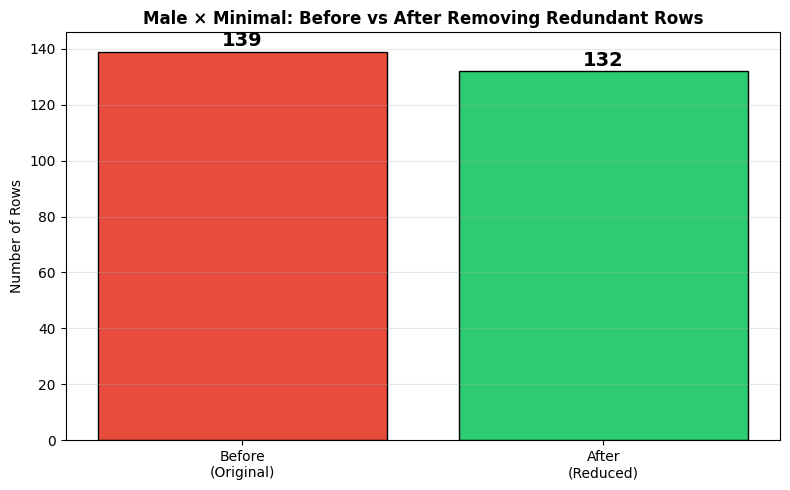


✅ Saved reduced data to 'maleXminimal_reduced.csv'


In [3]:
# STEP 3: Remove Redundant Rows (Keep 1 per Pattern)
# ===================================================

# Keep only one row per unique pattern (drop duplicates based on pattern columns)
pattern_cols = [col for col in df.columns if col != 'Age']

# Before
print(f"BEFORE: {len(df)} rows")

# Remove duplicates, keeping first occurrence
df_reduced = df.drop_duplicates(subset=pattern_cols, keep='first')

# After
print(f"AFTER:  {len(df_reduced)} rows")
print(f"REMOVED: {len(df) - len(df_reduced)} redundant rows ({(len(df) - len(df_reduced))/len(df)*100:.1f}%)")

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Before\n(Original)', 'After\n(Reduced)'], 
              [len(df), len(df_reduced)], 
              color=['#e74c3c', '#2ecc71'], 
              edgecolor='black')
ax.set_ylabel('Number of Rows')
ax.set_title('Male × Minimal: Before vs After Removing Redundant Rows', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add labels on bars
for bar, val in zip(bars, [len(df), len(df_reduced)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), 
            ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Save reduced data
df_reduced.to_csv('maleXminimal_reduced.csv', index=False)
print(f"\n✅ Saved reduced data to 'maleXminimal_reduced.csv'")